In [1]:
from enum import Enum
%matplotlib inline

from typing import Literal
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.stats import sigma_clip

from mirtos.core.type_defs.beam_map import BeamMap
from mirtos.filtering.filters import polynomial_trend
from mirtos.core.type_defs.scan import Scan
from mirtos.core.type_defs.config import load_config
from mirtos.core.projections import conv_radec_to_latlon
from mirtos.core.type_defs.mapmaking import MapMakingProjection, MapMakingFrame
from mirtos.plotting.map import plot_map
from mirtos.mapmaking.mapmaking import BinnerMapMaker

from scipy.optimize import curve_fit
from scipy.signal import welch, ShortTimeFFT, get_window

plt.style.use('dark_background')

In [2]:
def detrend_with_scipy(tod_, mask_):
    lin = lambda t, m, q: m*t + q

    tm__ = np.arange(tod_.shape[0])
    xdata = tm__[mask_]
    ydata = tod_[mask_]

    parfit, covfit = curve_fit(f=lin, xdata=xdata, ydata=ydata)
    lin_fit = lin(tm__, *parfit)
    return lin_fit, tod_ - lin_fit

def detrend_with_polynomial(time, tod_, deg):
    trend_ = polynomial_trend(time, tod_, deg=deg)
    return trend_, tod_ - trend_

In [3]:
def compute_lat_lon(scan_: Scan,
                    center_ra_rad: float, center_dec_rad: float,
                    projection: MapMakingProjection,
                    frame: MapMakingFrame):
    return conv_radec_to_latlon(
        scan_.ra,
        scan_.dec,
        center_ra_rad,
        center_dec_rad,
        projection,
        scan_.par_angle,
        scan_.ctx.beammap.beam_map['lon_offset'].to_numpy(),
        scan_.ctx.beammap.beam_map['lat_offset'].to_numpy(),
        frame)

# Confronto con vecchio codice

In [ ]:
config_path = Path("/Volumes/Data/PycharmProjects/mirtos/configs/cygA.yaml")

config = load_config(config_path)
scan = Scan.from_dir(config.paths.ra_dir, config.scan)
config.calibration.path = next(config.paths.gain_dir.iterdir(), None)
tod_raw = scan.subscans[0].kids[0].tod.copy()
scan.process(config.calibration, config.filtering)

## Confronto maschere (mode=cutted) & linear detrend

In [ ]:
root_target = Path("/Volumes/Data/PycharmProjects/mirtos/")
root_output = Path("/Volumes/Data/PycharmProjects/mirtos/notebooks")

mask_target = sorted(m for m in root_target.iterdir() if m.suffix == ".npy" and "target_dts" in m.stem)
mask_output = sorted(m for m in root_output.iterdir() if m.suffix == ".npy" and "output_dts" in m.stem)

global_max = -np.inf

for target, output in zip(mask_target, mask_output):
    t_ = np.load(target)
    o_ = np.load(output)

    diff = np.abs(t_ - o_)
    local_max = diff.max()
    global_max = max(global_max, local_max)

    if not np.allclose(t_, o_):
        print(f"[SHAPE] [filename: {target.stem}] target: {t_.shape}  | output: {o_.shape}")

    # print(f"[SHAPE] target: {target_lindetrend_mask.shape}  | output: {output_lindetrend_mask.shape}")
    # print(f"[TURE VALUES] target: {target_lindetrend_mask.sum()} | output: {output_lindetrend_mask.sum()}")
    # print(f"[ALL CLOSE]: {np.equal(target_lindetrend_mask, output_lindetrend_mask).all()}")

In [ ]:
mask_target[21]

In [ ]:
errs = []
for target, output in zip(mask_target, mask_output):
    A = np.load(target); B = np.load(output)
    errs.append((target.stem, np.max(np.abs(A - B))))

errs_sorted = sorted(errs, key=lambda x: x[1], reverse=True)
print("Top 10 worst files:")
for name, e in errs_sorted[:10]:
    print(name, f"{e:.6e}")

In [ ]:
# estraggo solo i valori degli errori
err_values = [e for _, e in errs_sorted]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(np.array(err_values) + 1e-30))

ax.set_xlabel("log10(max abs error)")
ax.set_ylabel("Count")
ax.set_title("Per-file max abs error (log scale)")

plt.show()

In [ ]:
fig, ax = plt.subplots(1,1, tight_layout=True)
t_ = np.load(mask_target[21])[100]
o_ = np.load(mask_output[21])[100]
ax.plot(t_, label="target")
ax.plot(o_, label="output")
#ax.plot(np.abs(t_ - o_), label="diff")
ax.legend()

print(f"Max abs error: {np.max(np.abs(t_ - o_)):.2e}")
# for k, (tod1, tod2) in enumerate(zip(out_, target_)):
#     if not np.allclose(tod1, tod2):
#         print(k)

In [ ]:
target_tod_dt = np.load("../target_dts_062.npy")
print(target_tod_dt.shape, scan.tods.shape, tod_raw.shape)

In [ ]:
# trend, output_dt_pol = detrend_with_polynomial(time_[mask_tod], tod_raw[mask_tod])

k = 0
kid = scan.kids[k]
output_tod_dt = kid.tod
lin_eval, output_dt_scipy_not = detrend_with_scipy(tod_raw, kid.mask)

tm_ = np.arange(len(tod_raw))

plt.plot(tm_, target_tod_dt[k], "o-", label=f"target kid:{k}", alpha=0.5)
plt.plot(tm_, output_tod_dt, "o-", label="output w/  scipy (filter.py)", alpha=0.3)
plt.plot(tm_, output_dt_scipy_not, "o-", label="output w/  scipy (notebook)", alpha=0.3)
# plt.plot(tm_[kid.mask], tod_raw[kid.mask], "o-", label=f"original tod for kid {k}", alpha=0.3)
#plt.plot(tm_, np.abs(output_dt - target_tod_dt[k]), label="diff")
plt.legend()

print(f"Max abs error: {np.max(np.abs(output_tod_dt - target_tod_dt[k]))}")

# Pulizia segnali

In [11]:
def em_svd_missing(X_nan: np.ndarray,
                   *,
                   rank: int,
                   init: Literal["row_mean", "zero", "global_mean","random", "none"] = "row_mean",
                   W_obs: np.ndarray | None = None,
                   min_iter: int = 5,
                   max_iter: int | None = 200,
                   tol: float = 1e-5,
                   seed: int | None = 42,
                   plot_losses: bool = False,
                   return_history: bool = False):

    """
    EM-SVD for matrices with missing entries (NaN).

    Minimizes || W ⊙ (X - X̂) ||_F^2 over rank-`rank` matrices,
    where W=1 on observed entries and 0 on missing, where
    `⊙` refers to element-wise multiplication

    Parameters
    ----------
    X_nan : (n_rows, n_cols) array with NaNs for missing entries.
    rank : target rank for low-rank reconstruction.
    init : initialization strategy for missing entries.
    W_obs:
    min_iter: minimum number of EM iterations.
    max_iter: maximum number of EM iterations.
    tol : convergence threshold on relative change of missing entries.
    seed : RNG seed for 'random' init.
    plot_losses: if True, plot both real/missing data losses
    return_history : if True, return dict with convergence history.

    Returns
    -------
    U, s, Vt, X_hat, info
      - U: (n_rows, rank)
      - s: (rank,)
      - Vt: (rank, n_cols)
      - X_hat: (n_rows, n_cols) low-rank reconstruction
      - info: dict with 'rel_change_missing',
                        'loss_obs',
                        'rmse_obs',
                        'rel_rmse_obs',
                        'n_obs',
                        'n_iter_done' and
                        'converged' keys
    """
    X = X_nan.copy()
    W = np.isfinite(X) if W_obs is None else W_obs.copy() # True where observed

    max_iter = max_iter or 100_000

    if not np.any(W):
        raise ValueError("W does not contain any observed entries")

    n_rows, n_cols = X.shape

    if (r := min(rank, n_rows, n_cols)) < 1:
        raise ValueError(f"rank must be >= 1, got {rank}")

    if max_iter < min_iter:
        raise ValueError(f"max_iter must be >= min_iter, got {max_iter} < {min_iter}")

    match init:
        case "row_mean":
            row_mean = np.nanmean(X, axis=1, keepdims=True)
            # in caso di righe completamente mancanti, sostituisco con media globale
            g = np.nanmean(X)
            row_mean = np.where(np.isfinite(row_mean), row_mean, g)
            X = np.where(W, X, row_mean)

        case "zero":
            X[~W] = 0.

        case "global_mean":
            g = np.nanmean(X)
            X[~W] = g

        case "random":
            rng = np.random.default_rng(seed)
            g, s = np.nanmean(X), np.nanstd(X)
            s = s if np.isfinite(s) and s else 1.
            # Sostituisco i valori mancanti con una frazione della media globale
            X[~W] = g + 0.01 * s * rng.standard_normal(size=(~W).sum())

        case "none":
            # Assumo che X sia gia' stata inizializzata con i valori corretti
            if np.any(~np.isfinite(X)):
                raise ValueError("X contains NaNs for missing entries")

        case _:
            raise ValueError(f"Invalid init: {init}")


    missing = ~W

    rel_hist = []
    loss_hist = []
    rmse_hist = []
    rel_rmse_hist = []
    eps = 1e-20

    n_obs = W.sum()
    rms_obs_ref = np.sqrt(np.mean(X_nan[W]**2))

    if (not np.isfinite(rms_obs_ref)) or (rms_obs_ref == 0):
        rms_obs_ref = 1.0

    for i in tqdm(range(max_iter), total=max_iter, desc="EM-SVD missing entries", leave=False):
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        U_r = U[:, :r]
        s_r = s[:r]
        Vt_r = Vt[:r, :]
        X_hat = (U_r * s_r) @ Vt_r

        # E-step: keep observed data, update only missing
        X_new = X.copy()
        X_new[missing] = X_hat[missing]

        # Convergence on missing entries (relative Frobenius change)
        num = np.linalg.norm((X_new - X)[missing])
        den = np.linalg.norm(X[missing]) + eps
        rel = num / den
        rel_hist.append(rel)

        res_obs = (X_nan - X_hat)[W]

        loss_obs = np.linalg.norm(res_obs)
        loss_hist.append(loss_obs)

        rmse_obs = np.sqrt(np.mean(res_obs**2))
        rmse_hist.append(rmse_obs)

        # RMSE relativa, adimensionale
        rel_rmse = rmse_obs / (rms_obs_ref + eps)
        rel_rmse_hist.append(rel_rmse)

        X = X_new

        if (i + 1) >= min_iter and rel < tol:
            break

    info = {
        "rel_change_missing": np.array(rel_hist),
        "loss_obs": np.array(loss_hist),
        "rmse_obs": np.array(rmse_hist),
        "rel_rmse_obs": np.array(rel_rmse_hist),
        "n_obs": n_obs,
        "n_iter_done": len(rel_hist),
        "converged": (len(rel_hist) >= min_iter and rel_hist[-1] < tol)
    }

    if plot_losses:
        fig, ax = plt.subplots(1, 1, figsize=(8, 4.5), tight_layout=True)

        it = np.arange(1, len(info["rmse_obs"]) + 1)

        rmse = info["rmse_obs"]
        relmiss = info["rel_change_missing"]

        # normalizzazione (rispetto al primo valore)
        rmse_n = rmse / (rmse[0] + eps)
        relmiss_n = relmiss / (relmiss[0] + eps)

        ax.semilogy(it, rmse_n, label="RMSE_obs / RMSE_obs[0]")
        ax.semilogy(it, relmiss_n, linestyle="--", label="rel_change_missing / rel_change_missing[0]")

        ax.set(xlabel="EM iteration", ylabel="Normalized value (log scale)",
               title="EM convergence (normalized)")
        ax.grid(alpha=0.2)
        ax.legend(loc="best")

    if return_history:
        return U_r, s_r, Vt_r, X_hat, info

    return U_r, s_r, Vt_r, X_hat

In [9]:
def sweep_rank_em(
    X_nan: np.ndarray,
    *,
    ranks: list[int] | np.ndarray,
    init: str = "row_mean",
    min_iter: int = 5,
    max_iter: int | None = 200,
    tol: float = 1e-5,
    seed: int | None = 42,
    warm_start: bool = True,
    plot: bool = True):

    """
    Sweep EM-SVD rank and plot final losses vs rank.

    Returns
    -------
    results : dict with arrays:
      - 'rank'
      - 'rmse_obs'
      - 'rel_rmse_obs'
      - 'loss_obs'
      - 'n_iter_done'
      - 'converged'
    """

    rmse_f = []
    relrmse_f = []
    loss_f = []
    niter_f = []
    conv_f = []

    # Warm start uses previous X_hat as filled init for next rank
    X_init = None
    W0 = np.isfinite(X_nan)
    max_iter = max_iter or 10_000

    for r in tqdm(ranks, desc="EM-SVD sweep rank"):
        if warm_start and (X_init is not None):
            # costruisco una matrice iniziale coerente coi NaN originali:
            init = "none"
            X0 = X_nan.copy()
            X0[~W0] = X_init[~W0]
            # EM parte da X0 come se fosse già inizializzata
            X_for_em = X0
        else:
            X_for_em = X_nan

        U, s, Vt, X_hat, info = em_svd_missing(
            X_for_em,
            rank=r,
            W_obs=W0,
            init=init,
            min_iter=min_iter,
            max_iter=max_iter,
            tol=tol,
            seed=seed,
            plot_losses=False,
            return_history=True)

        # metriche finali
        rmse_f.append(info["rmse_obs"][-1])
        relrmse_f.append(info["rel_rmse_obs"][-1])
        loss_f.append(info["loss_obs"][-1])
        niter_f.append(info["n_iter_done"])
        conv_f.append(info["converged"])

        X_init = X_hat  # warm start per il prossimo rank

    results = {
        "rank": np.array(ranks),
        "rmse_obs": np.array(rmse_f),
        "rel_rmse_obs": np.array(relrmse_f),
        "loss_obs": np.array(loss_f),
        "n_iter_done": np.array(niter_f),
        "converged": np.array(conv_f),
    }

    if plot:
        fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 4), tight_layout=True)
        ax.semilogy(results["rank"], results["rmse_obs"], "o-", label="RMSE_obs (final)")
        ax.semilogy(results["rank"], results["rel_rmse_obs"], "o-", label="relRMSE_obs (final)")
        ax.set(xlabel="Rank", ylabel="Error", title="EM-SVD: final error vs rank")
        ax.grid(alpha=0.2)
        ax.legend()

        # mostra iterazioni / convergenza
        ax2.plot(results["rank"], results["n_iter_done"], "o-", label=r"\# iterations")
        ax2.set(xlabel="Rank", ylabel="Iterations", title="EM-SVD: iterations vs rank")
        ax2.grid(alpha=0.2)
        ax2.legend()

    return results

In [6]:
config_path = Path("/Volumes/Data/PycharmProjects/mirtos/configs/3c84.yaml")

config = load_config(config_path)
scan = Scan.from_dir(config.paths.ra_dir, config.scan)
config.calibration.path = next(config.paths.gain_dir.iterdir(), None)

# scan.process(config.calibration, config.filtering)

In [ ]:
class MaskType(Enum):
    SIGMA_CLIP = "sigma_clip"
    SPATIAL = "polynomial"

def get_mask(scan_,
             mask_type: MaskType = MaskType.SPATIAL,
             radius_arcsec_: u.Quantity = 0.,
             sigma: float = 6,
             maxiters: int = 10):

    if mask_type == MaskType.SPATIAL:
        if not radius_arcsec_.value:
            raise ValueError("radius_arcsec must be a non-zero value")

        lat, lon = compute_lat_lon(scan,
                                   center_ra_rad=scan.ctx.ra_center,
                                   center_dec_rad=scan.ctx.dec_center,
                                   projection=scan.ctx.projection,
                                   frame=scan.ctx.frame)

        radius_rad = radius_arcsec.to_value(u.rad)
        dist = np.sqrt(lon**2 + lat**2) >= radius_rad

        return dist

    tods = scan_.tods

    if mask_type == MaskType.SIGMA_CLIP:
        return ~sigma_clip(tods,
                           sigma=sigma,
                           maxiters=maxiters,
                           axis=1).mask


    return None


/Volumes/Data/PycharmProjects/mirtos/src/mirtos/core/type_defs/scan.py:365: UserWarning: Not all subscans have been processed.
  warnings.warn(category=None, message="Not all subscans have been processed.")


Valid KIDs: 100.00%


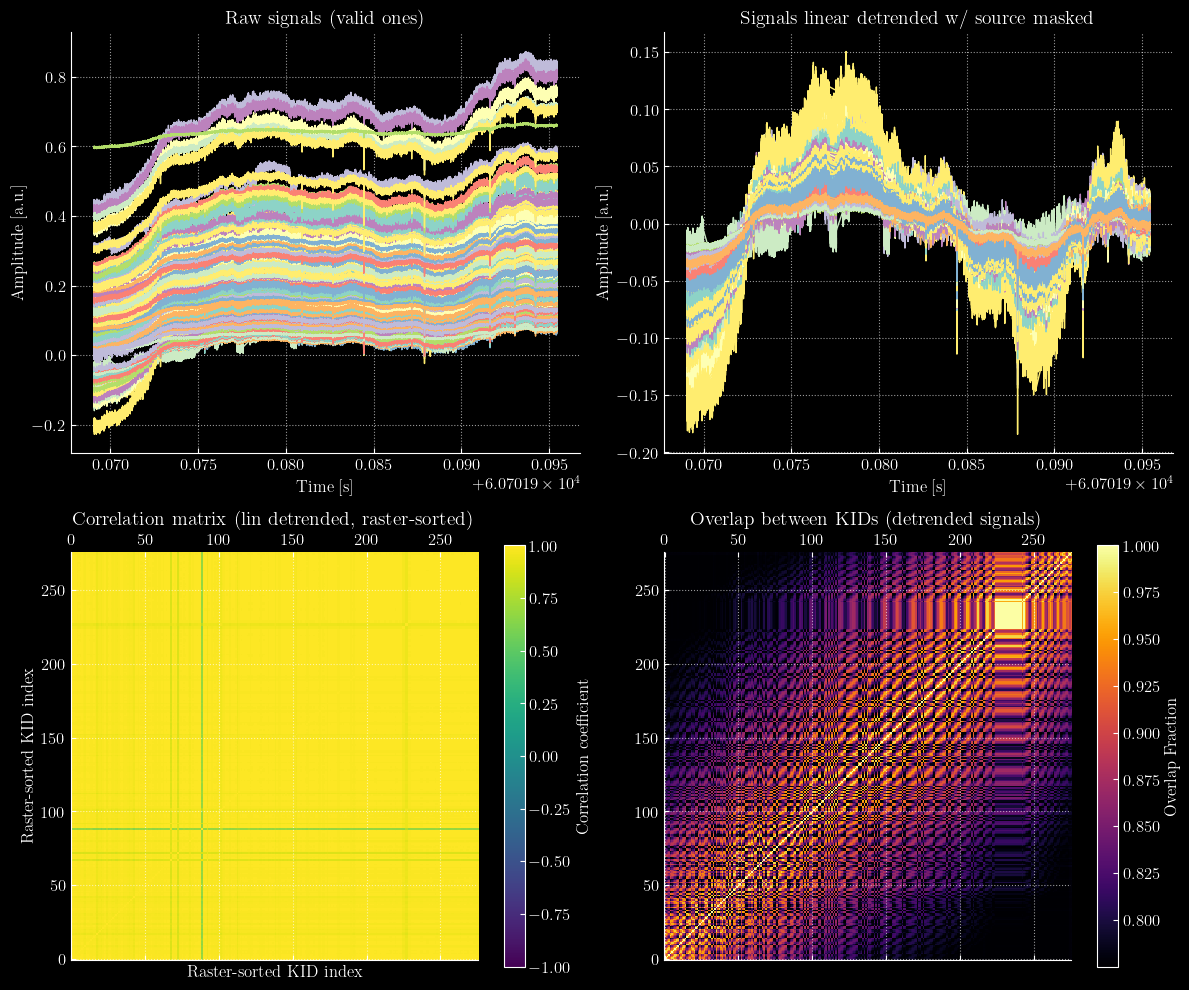

In [8]:
fig, ((ax_raw, ax_detrend), (ax_dt_corr, ax_dt_corr_overlap)) = plt.subplots(2, 2, figsize=(12, 10), tight_layout=True)
ax_raw.set(title="Raw signals (valid ones)", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
ax_detrend.set(title="Signals linear detrended w/ source masked",  xlabel="Time [s]", ylabel="Amplitude [a.u.]")

scan_kids = scan.kids

# ordinamento raster (geometrico, in riferimento al piano focale)
# kids_valid_sorted = sorted([kid for kid in scan_kids if kid.is_valid], key=lambda k: (k.pos.y, k.pos.x))
#
# ordinamento radiale (distanza dal centro)
# kids_valid_sorted = sorted([kid for kid in scan_kids], key=lambda k: k.pos.r) # if kid.is_valid
# ordinamento polare (spirale intorno al centro, utile per pattern angolari)
#kids_valid_sorted = sorted([kid for kid in scan_kids], key=lambda k: (k.pos.theta, k.pos.r))

kids_valid_sorted = sorted(scan_kids, key=lambda k_: (k_.pos.y, k_.pos.x))

kids_ids = np.array([kid.id for kid in kids_valid_sorted])
id_to_row = {kid_id: index for index, kid_id in enumerate(kids_ids)}

bm = scan.ctx.beammap = BeamMap.from_dat(scan.ctx.beammap_filename, valid_kids=True)
beam_ids = bm.beam_map.index.to_numpy(dtype=int)
id_to_beamrow = {kid_id: i for i, kid_id in enumerate(beam_ids)}

n_kids, n_samples = len(kids_valid_sorted), len(scan.time)

tods_detrend = np.full((n_kids, n_samples), np.nan)
tods_masks = np.zeros((n_kids, n_samples), dtype=bool)

use_spatial_mask = True
radius_arcsec = u.Quantity(66, u.arcsec)

if use_spatial_mask:
    lat, lon = compute_lat_lon(scan,
                               center_ra_rad=scan.ctx.ra_center,
                               center_dec_rad=scan.ctx.dec_center,
                               projection=scan.ctx.projection,
                               frame=scan.ctx.frame)

    radius_rad = radius_arcsec.to_value(u.rad)
    dist = np.sqrt(lon**2 + lat**2)

for row, kid in enumerate(kids_valid_sorted):
    # True = no sorgente
    if use_spatial_mask:
        mask_tod = dist[id_to_beamrow[kid.id]] >= radius_rad
    else:
        mask_tod = ~sigma_clip(kid.tod, sigma=6, maxiters=10).mask

    # FIXME: qui dobbiamo cambiare approccio. Sostituire i False (quindi la sorgente) con 0
    #  prima di effettuare la SVD porta alla creazione artificiale di clusters che poi puo'
    #  inquinare la decomposizione. Devo trovare la massima lunghezza di campioni contigui
    #  relativa ai punti del rumore e scomporre quest'ultima. Il problema e' che poi non
    #  ho piu' coerenza tra el dimensioni di `tods_detrend` e kid.tod
    tods_masks[row, mask_tod] = True

    tm_ = scan.time[mask_tod]
    sig_ = kid.tod[mask_tod]

    ax_raw.plot(tm_, sig_)
    _, output_dt_pol = detrend_with_polynomial(tm_, sig_, deg=1)

    tods_detrend[row, mask_tod] = output_dt_pol

    ax_detrend.plot(tm_, output_dt_pol)

print(f"Valid KIDs: {len(kids_valid_sorted) / len(scan_kids):.2%}")

df = pd.DataFrame(tods_detrend.T, columns=kids_ids)
corr = df.corr()
im = ax_dt_corr.matshow(corr, origin="lower", vmin=-1, vmax=1)
ax_dt_corr.set(title="Correlation matrix (lin detrended, raster-sorted)",
               xlabel="Raster-sorted KID index",
               ylabel="Raster-sorted KID index")
fig.colorbar(im, ax=ax_dt_corr, label="Correlation coefficient")

M = df.notna().to_numpy(dtype=int)
overlap = M.T @ M  # (N_KIDs, N_KIDs)
n_i = M.sum(axis=0) # (N_KIDs,) e' il numero di campioni validi per ogni kid
# Normalizzazione
#
# Intersection Over Union (Jaccard)
# J_(i, j) = Overlap(i, j) / ( Union(i, j) - Overlap(i, j))
# n_i = campioni validi kid i
# n_j = campioni validi kid j
#
# Matrice simmetrica: J_(i, j) = J_(j, i)
# Normalizzazione:
#   1: maschere identiche
#   0: nessun overlap
#   Non dipende da chi ha piu' campioni validi
#   Stabile per frazioni mascherate di diversa dimensione
#
# - divisione per max (n_i, n_j): misura l'overlap relativo all'unione piu' grande
# - divisione per min (n_i, n_j): misura l'overlap relativo all'intersezione piu' grande
#
# Se divido per min(n_i, n_j) rischio di avere sempre 1 anche se:
# - kid sempre valido
# - altro kid valido solo in una piccola finestra
#
# Non divido per il massimo tra n_i, n_j perche' avrei sempre overlap <= 1, penalizzando
# pero' i casi in cui una maschera e' contenuta nell'altra
# Esempio:
# kid i ha 1000 elementi validi
# kid j ha 100 elementi validi
# j e' sottoinsieme di i, cioe' tutti i campioni validi di j sono contenuti in i
# Se divido con max: 100/1000 = 0.1, ovvero overlap = 0.1 ma in realta' e' totale (rispetto ad j)

# IoU - Jaccard
den = n_i[:, None] + n_i[None, :] - overlap
overlap = overlap.astype(float) /  den
overlap[den == 0] = 0.0
olp_im = ax_dt_corr_overlap.matshow(overlap, cmap="inferno", origin="lower")
ax_dt_corr_overlap.set(title="Overlap between KIDs (detrended signals)")
fig.colorbar(olp_im, ax=ax_dt_corr_overlap, label="Overlap Fraction")
fig.savefig("analysis.png", dpi=1000)

# SVD Analysis

In [9]:
X = tods_detrend.copy()

# centro le tod per riga
X -= np.nanmean(X, axis=1, keepdims=True)

EM-SVD missing entries:   0%|          | 0/50 [00:00<?, ?it/s]

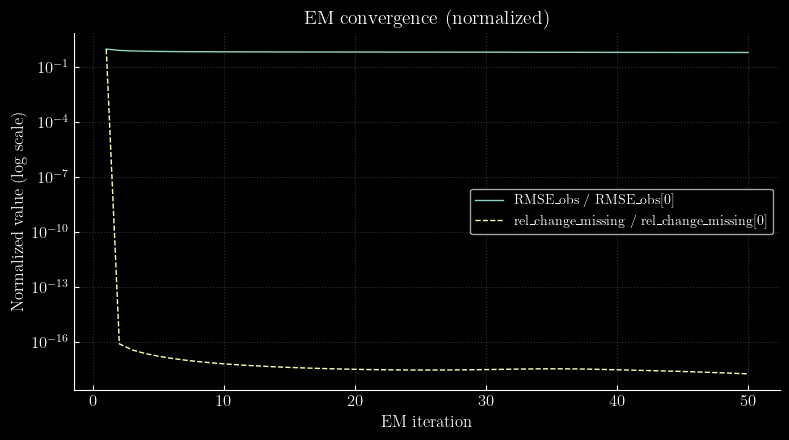

In [10]:
U, s, V, X_hat, info = em_svd_missing(X,
                                      rank=6,
                                      max_iter=50,
                                      plot_losses=True,
                                      return_history=True)

# Rank Selection (EM-SVD)

EM-SVD sweep rank:   0%|          | 0/10 [00:00<?, ?it/s]

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

...

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

EM-SVD missing entries:   0%|          | 0/10000 [00:00<?, ?it/s]

[ 1  2  3  5  8 10 15 20 30 50]
[0.14147838 0.11929795 0.10496083 0.09794737 0.09220912 0.08942
 0.08381744 0.07915914 0.07116823 0.05798394]
[ True  True  True  True  True  True  True  True False False]


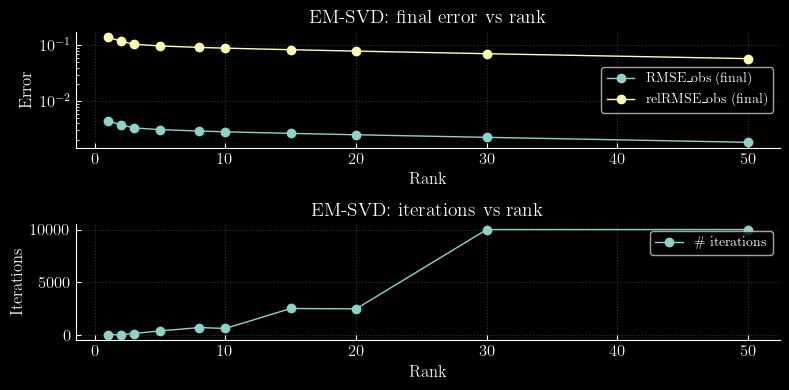

In [10]:
X = tods_detrend.copy()
X -= np.nanmean(X, axis=1, keepdims=True)

ranks = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50]

res = sweep_rank_em(
    X,
    ranks=ranks,
    init="row_mean",     # usato solo per il primo rank (poi warm_start => init="none")
    min_iter=5,
    max_iter=None,
    tol=1e-5,
    warm_start=True,
    plot=True)

print(res["rank"])
print(res["rel_rmse_obs"])
print(res["converged"])

In [ ]:
# sostituisco nan con 0
# X[np.isnan(X)] = 0
U, s, V = np.linalg.svd(X, full_matrices=False)

In [ ]:
fig_sing_values, (ax_s, ax_var_frac) = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)
ax_s.semilogy(s, "o-", label="Singular values")
# spettro piatto: rumore indipendente per detector
# valori ~ 0: errore legato alla precisione numerica
ax_s.set(xlabel="Mode Index", ylabel="S", title="Singular values")

variance_fraction = s**2 / (s**2).sum()

ax_var_frac.set(xlabel="Mode Index", ylabel=r"$\frac{s^{2}}{total}$", title="Variance fraction per mode")
ax_var_frac.plot(variance_fraction, "o-", label=rf"first mode variance: {variance_fraction[0]:.2%}")
ax_var_frac.legend()
fig_sing_values.savefig("singular_values.png", dpi=1000)
print("First mode variance fraction: ", variance_fraction[0])

In [ ]:
s[:10]

In [ ]:
def plot_svd_modes(*,
                   U_: np.ndarray,
                   V_: np.ndarray,
                   kids: list,
                   kids_ids: np.ndarray | None = None,
                   n_modes: int = 5,
                   figsize_per_mode: tuple[float, float] = (18, 6),
                   cmap: str = "coolwarm",
                   point_size: float = 80,
                   alpha: float = 0.9,
                   title: str | None = None,
                   savepath: str | None = None,
                   dpi: int = 1000,
                   cbar_shift_left: float = 0.025,   # move cbar left (in figure coords)
                   cbar_width_ratios: tuple[float, float, float, float] = (1.2, 1.2, 0.04, 1.25),
                   cbar_label: str = "U weight",
                   cbar_labelpad: float = 18.0,
                   symmetric_cbar: bool = True,
                   fix_sign: bool = True,
                   max_id_ticks: int = 10):
    """
    Plot SVD modes in a standard layout (rows=modes):
        | U(mode) | Spatial map | Colorbar | V(mode) |

    Notes
    -----
    - `kids` must be in the SAME order used to build X rows.
    - `V_` is the Vt returned by np.linalg.svd(X, full_matrices=False), i.e. shape (r, n_samples).
    - Uses a shared color normalization across all plotted modes and a single shared colorbar.
    """

    x_pos = np.array([kid.pos.x for kid in kids])
    y_pos = np.array([kid.pos.y for kid in kids])

    n_modes = min(n_modes, U_.shape[1], V_.shape[0])

    fig_h = figsize_per_mode[1] * n_modes

    # Mosaic layout: 4 columns: U | Spatial | Cbar | V
    mosaic = [[f"U{m}", f"XY{m}", "CBAR", f"V{m}"] for m in range(n_modes)]

    fig, axes = plt.subplot_mosaic(
        mosaic,
        figsize=(figsize_per_mode[0], fig_h),
        gridspec_kw={"width_ratios": list(cbar_width_ratios)})

    for ax in axes.values():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Copies for plotting (and optional sign convention)
    U_plot = U_.copy()
    V_plot = V_.copy()

    # Shared normalization for one colorbar
    U_block = U_plot[:, :n_modes]
    if symmetric_cbar:
        u_lim = np.max(np.abs(U_block))
        vmin, vmax = -u_lim, u_lim
    else:
        vmin, vmax = np.min(U_block), np.max(U_block)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    n_kids = len(kids)
    raster_idx = np.arange(n_kids)

    use_ids = (kids_ids is not None) and (len(kids_ids) == n_kids)
    if use_ids:
        step = max(1, int(np.ceil(n_kids / max_id_ticks)))
        id_tick_pos = raster_idx[::step]
        id_tick_lab = kids_ids[::step]

    for mode in range(n_modes):

        # Fix sign flip ambiguity
        if fix_sign and (np.mean(U_plot[:, mode]) < 0):
            U_plot[:, mode] *= -1
            V_plot[mode, :] *= -1

        ax_u  = axes[f"U{mode}"]
        ax_xy = axes[f"XY{mode}"]
        ax_v  = axes[f"V{mode}"]

        # U(mode)
        ax_u.plot(raster_idx, U_plot[:, mode])
        ax_u.set_ylabel("Weight")
        ax_u.set_title(f"U[:, {mode}] (spatial weights)")
        ax_u.grid(alpha=0.2)

        if mode == n_modes - 1:
            ax_u.set_xlabel("Raster-sorted KID index")
            if use_ids:
                ax_u.set_xticks(id_tick_pos)
                ax_u.set_xticklabels(id_tick_lab, rotation=45, ha="right")
                ax_u.set_xlabel("KID id (raster-sorted)")
        else:
            ax_u.tick_params(labelbottom=False)

        # Spatial map
        ax_xy.scatter(
            x_pos, y_pos,
            c=U_plot[:, mode],
            cmap=cmap,
            norm=norm,
            s=point_size,
            alpha=alpha)

        ax_xy.set_axis_off()

        # keep equal aspect w/o shrinking the axes box
        ax_xy.set_aspect("equal", adjustable="datalim")

        ax_xy.set_ylabel("Y")
        ax_xy.set_title("Spatial map (X,Y)")

        if mode == n_modes - 1:
            ax_xy.set_xlabel("X")
        else:
            ax_xy.tick_params(labelbottom=False)

        #  V(mode) 
        ax_v.plot(V_plot[mode, :])
        ax_v.set_ylabel("Amplitude")
        ax_v.set_title(f"V[{mode}, :] (temporal mode)")
        ax_v.grid(alpha=0.2)

        if mode == n_modes - 1:
            ax_v.set_xlabel("Time sample")
        else:
            ax_v.tick_params(labelbottom=False)

    # Single shared colorbar
    cbar_ax = axes["CBAR"]
    cbar = fig.colorbar(sm, cax=cbar_ax)

    # # Label handling (avoid overlapping with V ylabel)
    # if cbar_label:
    #     cbar.set_label(cbar_label, labelpad=cbar_labelpad)

    # shift the whole colorbar axis left a bit (to avoid covering V's ylabel)
    if cbar_shift_left:
        pos = cbar_ax.get_position()
        cbar_ax.set_position([pos.x0 - float(cbar_shift_left), pos.y0, pos.width, pos.height])

    if title is not None:
        fig.suptitle(title)

    if savepath is not None:
        fig.savefig(savepath, dpi=dpi)

    return fig, axes

In [ ]:
fig_modes, _ = plot_svd_modes(
    U_=U,
    V_=V,
    kids=kids_valid_sorted,
    n_modes=3,
    kids_ids=kids_ids,
    title=r"SVD modes: $|$ U(mode) $|$ Spatial map $|$ V(mode) $|$",
    savepath="svd_modes_standard.png",
    dpi=1000)

In [ ]:
def Spectrogram(*,
                x: np.ndarray,
                fs: float,
                n_samples: int | None = None,
                nperseg: int = 4096,
                hop: int | None = None,
                window: str = "hann",
                fft_mode: str = "onesided",
                scale_to: str = "psd",
                power_db: bool = True,
                eps: float = 1e-20,
                fmax: float | None = None,
                ax: plt.Axes | None = None,
                title: str | None = None,
                cmap: str = "viridis",
                add_colorbar: bool = True):
    """
    Compute and optionally plot a ShortTimeFFT-based spectrogram.

    Returns dict:
      {'f','t','Zxx','P','P_plot','im'}
    """

    if n_samples is None:
        n_samples = len(x)

    if hop is None:
        hop = nperseg // 4

    w = get_window(window, nperseg, fftbins=True)
    stft = ShortTimeFFT(w, hop=hop, fs=fs, fft_mode=fft_mode, scale_to=scale_to)

    Zxx = stft.stft(x)     # (n_freq, n_time)
    f = stft.f
    t = stft.t(n_samples)

    P = np.abs(Zxx) ** 2
    P_plot = 10.0 * np.log10(P + eps) if power_db else P

    im = None
    if ax is not None:
        im = ax.pcolormesh(t, f, P_plot, shading="auto", cmap=cmap)

        idx = np.argmax(P, axis=0)
        f_dom = f[idx]

        line, = ax.plot(t, f_dom, lw=1.5, label=f"f_dom median={np.median(f_dom):.3g} Hz")
        ax.legend(loc="upper right")

        ax.set_ylabel("Frequency [Hz]")
        if fmax is not None:
            ax.set_ylim(0, fmax)
        if title is not None:
            ax.set_title(title)
        if add_colorbar:
            cbar = ax.figure.colorbar(im, ax=ax)
            cbar.set_label("Power [dB]" if power_db else "Power")

    return {"f": f, "t": t, "Zxx": Zxx, "P": P, "P_plot": P_plot, "im": im}

In [ ]:
def analyze_temporal_modes_spectrum(*,
                                    V_: np.ndarray,
                                    fs: float,
                                    modes: list[int] | None = None,
                                    # Spatial stats
                                    U_: np.ndarray | None = None,
                                    compute_stats: bool = False,
                                    f_cut: float = 1.0,
                                    # Welch
                                    do_welch: bool = True,
                                    welch_nperseg: int = 4096,
                                    welch_noverlap: int | None = None,
                                    welch_nfft: int | None = None,
                                    welch_window: str = "hann",
                                    welch_detrend: str | bool = "constant",
                                    welch_scaling: str = "density",
                                    welch_average: str = "mean",
                                    # ShortTimeFFT
                                    do_stft: bool = True,
                                    stft_nperseg: int = 4096,
                                    stft_hop: int | None = None,          # samples
                                    stft_window: str = "hann",
                                    stft_fft_mode: str = "onesided",      # onesided/twosided (SciPy API)
                                    stft_scale_to: str = "psd",
                                    # Output/plot
                                    power_db: bool = True,
                                    eps: float = 1e-20,
                                    plot: bool = True,
                                    fmax: float | None = None,
                                    figsize: tuple[float, float] = (14, 3.6),
                                    savepath_prefix: str | None = None,
                                    dpi: int = 300):
    """
    Spectral analysis for temporal SVD modes using Welch PSD and ShortTimeFFT (time-frequency).

    If compute_stats=True and U_ is provided, also compute:
      - spatial_uniformity = std(U[:,m]) / |mean(U[:,m])|
      - spatial_localization = max(|U[:,m]|) / rms(|U[:,m]|)
    and always compute:
      - low_freq_fraction = power below f_cut / total power (Welch PSD of V_[m,:])

    Returns
    -------
    results : dict
        results[m]['welch'] -> {'f', 'Pxx'}
        results[m]['stft']  -> {'f', 't', 'Zxx', 'P'}   where P is power/PSD map (linear)
    """

    r, n = V_.shape
    if modes is None:
        modes = [0, 1, 2]

    modes = list(filter(lambda m: 0 <= m < r, modes))

    if welch_noverlap is None:
        welch_noverlap = welch_nperseg // 2

    if stft_hop is None:
        stft_hop = stft_nperseg // 4

    # uso welch per ottenere la PSD e quindi calcolare le statistiche spaziali
    do_welch = do_welch or compute_stats

    results: dict[int, dict] = {}

    for m in modes:
        x = V_[m, :]

        results[m] = {}

        f, Pxx = None, None
        if do_welch:
            f, Pxx = welch(
                x,
                fs=fs,
                window=welch_window,
                nperseg=welch_nperseg,
                noverlap=welch_noverlap,
                nfft=welch_nfft,
                detrend=welch_detrend,
                scaling=welch_scaling,
                average=welch_average)

            results[m]["welch"] = {"f": f, "Pxx": Pxx}

        if do_stft:
            # Create ShortTimeFFT object
            # Notes:
            # - hop is in samples
            # - fs sets frequency axis in Hz
            out_stft = Spectrogram(
                x=x,
                fs=fs,
                n_samples=n,
                nperseg=stft_nperseg,
                hop=stft_hop,
                window=stft_window,
                fft_mode=stft_fft_mode,
                scale_to=stft_scale_to,
                power_db=power_db,
                eps=eps,
                fmax=fmax,
                ax=None,              # plotting handled below
                add_colorbar=False
            )
            results[m]["stft"] = {
                "f": out_stft["f"],
                "t": out_stft["t"],
                "Zxx": out_stft["Zxx"],
                "P": out_stft["P"]}

        # compute stats for each mode
        if compute_stats and Pxx is not None:
            stats_m = {}
            total_power = np.trapezoid(Pxx, f)
            lf_mask = f <= f_cut

            # Low-frequency Fraction
            # misura quanto il modo e' dominato da basse frequenze
            # Se   ~1: domainato da 1/f, drift lento (probabile atmosfera)
            # Se ~0.5: misto
            # Se   ~0: rumore bianco
            lf_power = np.trapezoid(Pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else 0.0
            stats_m["low_freq_fraction"] = lf_power / (total_power + eps)

            if U_ is not None:
                u = U_[:, m]
                mu = u.mean()
                std = u.std()
                abs_u = np.abs(u)

                # Spatial uniformity: std(U[mode, :]) / |mean(U[mode, :])|
                # misura quanto il modo e' uniforme su tutto il piano focale
                # Se tutti contribuiscono allo stesso modo: media >> std: valore minimo
                # Se alcuni KIDs dominano: std grande: valore medio/elevato
                stats_m["spatial_uniformity"] = std / (abs(mu) + eps)

                # Spatial localization: max(U[mode, :]) / RMS(|U[mode, :]|)
                # misura quanto il modo e' centrato su pochi KID:
                # Se tutti contribuiscono allo stesso modo: max ~ rms ~= 1
                # Se pochi KIDs dominano: max >> rms = >1
                stats_m["spatial_localization"] = np.max(abs_u) / (np.sqrt(np.mean(abs_u ** 2)) + eps)

            else:
                stats_m["spatial_uniformity"] = np.nan
                stats_m["spatial_localization"] = np.nan

            results[m]["stats"] = stats_m

    if plot:
        nrows = len(modes)

        if do_welch:
            fig_psd, axes_psd = plt.subplots(nrows, 1, figsize=(figsize[0], figsize[1] * nrows), tight_layout=True, sharex=True)
            axes_psd = np.atleast_1d(axes_psd)

            for i, m in enumerate(modes):
                ax = axes_psd[i]
                f = results[m]["welch"]["f"]
                Pxx = results[m]["welch"]["Pxx"]
                y = 10.0 * np.log10(Pxx + eps) if power_db else Pxx

                ax.plot(f, y)
                ax.set_title(f"Welch PSD mode - {m} (V[{m}, :])")
                ax.set_ylabel("PSD [dB/Hz]" if power_db else "PSD")
                ax.grid(alpha=0.2)

                if fmax is not None:
                    ax.set_xlim(0, fmax)

            axes_psd[-1].set_xlabel("Frequency [Hz]")

            if savepath_prefix is not None:
                fig_psd.savefig(f"{savepath_prefix}_welch.png", dpi=dpi)

        if do_stft:
            fig_tf, axes_tf = plt.subplots(nrows, 1, figsize=(figsize[0], figsize[1] * nrows), tight_layout=True, sharex=True)
            axes_tf = np.atleast_1d(axes_tf)

            for i, m in enumerate(modes):
                ax = axes_tf[i]
                f = results[m]["stft"]["f"]
                t = results[m]["stft"]["t"]
                P = results[m]["stft"]["P"]

                Z = 10.0 * np.log10(P + eps) if power_db else P

                idx = np.argmax(P, axis=0)  # (n_time,)
                f_dom = f[idx]

                im = ax.pcolormesh(t, f, Z, shading="auto")
                ax.set_title(f"ShortTimeFFT - mode {m}  (V[{m}, :])")
                ax.set_ylabel("Frequency [Hz]")

                line, = ax.plot(t, f_dom, lw=1.5, label=f"f_dom median={np.median(f_dom):.3g} Hz")
                ax.legend(loc="upper right")

                ax.grid(False)

                if fmax is not None:
                    ax.set_ylim(0, fmax)

                cbar = fig_tf.colorbar(im, ax=ax)
                cbar.set_label("Power [dB]" if power_db else "Power")

            axes_tf[-1].set_xlabel("Time [s]")

            if savepath_prefix is not None:
                fig_tf.savefig(f"{savepath_prefix}_shorttimefft.png", dpi=dpi)

    return results

In [ ]:
from astropy.time import Time
# Il tempo e' in Modified Julian Date (MDJ) che rappresenta il tempo in giorni espressi in float
# Giorno zero: 1 gennaio 4713 a.C, 12:00 UTC
# Parte intera: giorno, Parte decimale: frazione del giorno (ore, min, sec)
# Esempio:
# 60701.96905163
# Giorno MJD 60701
# 1 giorno = 86400 secondi
# .96905163 * 86400 ~ 83701 sec ~ 23:15:01
# MJD 60701.96905163 ~ 26 gennaio 2025 23:15 UTC

t = Time(scan.time, format="mjd", scale="utc")
print(f"Start: {t[0].isot}, End: {t[-1].isot}")

In [ ]:
# per convertire in secondi, moltiplico per numero di secondi in un giorno
dt = np.median(np.diff(scan.time)) * 86400.
fs = 1. / dt

print(f"Sampling frequency: {fs:.2f} Hz")
res = analyze_temporal_modes_spectrum(
    V_=V,
    U_=U,
    fs=fs,
    modes=[0, 1, 2, 3],
    welch_window="blackman",
    stft_window="blackman",
    do_welch=True,
    do_stft=True,
    stft_nperseg=8192,
    stft_hop=2048,
    # fmax=5.0,
    savepath_prefix="modes_spec",
    compute_stats=True)

In [ ]:
res[2]['stats']

In [ ]:
fig_az, (ax_az_tm, ax_az_f) = plt.subplots(2, 1, figsize=(10, 4), tight_layout=True)

sub = scan[0]
det_az = sub.az - polynomial_trend(None, sub.az, 1)
ax_az_tm.plot(sub.time, np.unwrap(det_az))

Spectrogram(
    x=det_az,
    fs=fs,
    nperseg= 512, #8192,
    hop=64, #2048,
    window="blackman",
    power_db=True,
    ax=ax_az_f,
    title="ShortTimeFFT - Azimuth",
    add_colorbar=True)

ax_az_f.set_xlabel("Time [s]")


In [ ]:
def remove_modes_and_make_corr(*,
                               X_: np.ndarray,
                               U_: np.ndarray,
                               s_: np.ndarray,
                               V_: np.ndarray,
                               n_modes: int,
                               vmin: float = -1.0,
                               vmax: float = 1.0,
                               df_cols: np.ndarray = None):

    tot_plots = 1 + n_modes

    ncols = int(np.ceil(np.sqrt(tot_plots)))
    nrows = int(np.ceil(tot_plots / ncols))

    fig_, axes = plt.subplots(nrows, ncols,figsize=(5 * ncols, 4.5 * nrows), tight_layout=True)
    fig_.suptitle("Correlation matrix after removing modes (linear detrended signals)")

    # flatten assi
    axes = np.atleast_1d(axes).ravel()

    def _corr_of(Xmat: np.ndarray) -> pd.DataFrame:
        # colonne = KID, righe = tempo
        df_ = pd.DataFrame(Xmat.T, columns=df_cols)
        return df_.corr()

    def _plot(ax, Xmat, title):
        corr_ = _corr_of(Xmat)
        im_ = ax.matshow(corr_, origin="lower", vmin=vmin, vmax=vmax)
        ax.set(title=title, xlabel="KID index", ylabel="KID index")
        return im_

    X_clean = X_.copy()

    # (0) base
    im0 = _plot(axes[0], X_clean, "No modes removed")
    fig_.colorbar(im0, ax=axes[0], label="Correlation")

    # (1..n_modes) rimuovo progressivamente
    for m in range(n_modes):
        mode_m = s_[m] * np.einsum("i, j -> ij", U_[:, m], V_[m, :])   # (n_kids, n_samples)
        X_clean = X_clean - mode_m

        im = _plot(axes[m + 1], X_clean, f"After removing mode {m}")
        fig_.colorbar(im, ax=axes[m + 1], label="Correlation")

    # rimuovo eventuali subplot extra
    for ax in axes[tot_plots:]:
        ax.axis("off")

    return X_clean, fig_, axes

In [ ]:
X_decor, fig_corr_with_modes, ax = remove_modes_and_make_corr(X_=X, V_=V, U_=U, s_=s, n_modes=5, df_cols=kids_ids)
fig_corr_with_modes.savefig("corr_with_modes_removed.png", dpi=1000)

# Re-introduzione Rumore Decorrelato

In [ ]:
# numero di modi da rimuovere:
k = 5
# rumore correlato da sottrarre
N_hat = (U[:, :k] * s[:k]) @ V[:k, :] # (KIDs, samples)

t = np.arange(n_samples)
tods_clean = np.zeros((n_kids, n_samples))

for row, kid in enumerate(kids_valid_sorted):
    tod_full = kid.tod
    mask = tods_masks[row]

    # fit lineare stimato su mask ma sottratto a tutta la tod
    lin_fit, tod_detr = detrend_with_scipy(tod_full, mask)

    # centro la tod. Stimo la media su mask e sottraggo a tutta la tod
    mu = tod_detr[mask].mean()
    tod_center = tod_detr - mu
    # Sottraggo rumore correlato stimato via SVD
    tods_clean[row, :] = tod_center - N_hat[row, :]

In [ ]:
t0 = 0
for sub in scan.subscans:
    n = len(sub.time)
    sl = slice(t0, t0 + n)

    for k in sub.kids:
        row = id_to_row.get(k.id, None)
        if row is None:
            continue  # kid non presente nel raster-set (es. invalid / escluso)

        #  sovrascrivo tutta la TOD del subscan
        k.tod[:] = tods_clean[row, sl]

    t0 += n

In [ ]:
scan.ctx.beammap = BeamMap.from_dat(scan.ctx.beammap_filename, valid_kids=True)

lat, lon = compute_lat_lon(scan,
                           center_ra_rad=scan.ctx.ra_center,
                           center_dec_rad=scan.ctx.dec_center,
                           projection=scan.ctx.projection,
                           frame=scan.ctx.frame)

scan._processed = True

binner_mm = BinnerMapMaker(scans=[scan], pixel_size=config.map_making.pixel_size, npix=config.map_making.npix)
data_map_, count_map_, wcs_ = binner_mm.make_map()
plot_map(data_map_,
         count_map_,
         wcs_,
         title="",
         colorbar_label="Phases [rad]",
         savepath="map.png")

plt.show()